In [4]:
%load_ext autoreload
%autoreload 2

In [24]:
import os
import tempfile
from pathlib import Path
from typing import Literal

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import sqlalchemy

from ageb_alignment.defs.assets.gcp import (
    get_clique_geometries,
    get_vertices,
    merge_columns,
)
from ageb_alignment.defs.assets.translate.common import generate_options_str
from ageb_alignment.defs.assets.translate.translate_2000 import (
    translate_geometries_single,
)
from ageb_alignment.defs.assets.zones.extended import get_outer_polygon
from ageb_alignment.defs.assets.zones.initial import remove_multipoly

In [6]:
MET_ZONE = "19.1.01"

In [7]:
data_path = Path(os.environ["DATA_PATH"])

# Load census

In [8]:
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}@{os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}/{os.environ['POSTGRES_DB']}"
)

In [9]:
def load_agebs(year: Literal[1990, 2000, 2010, 2020]) -> gpd.GeoDataFrame:
    if year == 2020:
        query = """
            SELECT census_2020_ageb.cvegeo, census_2020_ageb.pobtot, census_2020_ageb.geometry
                FROM census_2020_ageb
            INNER JOIN census_2020_mun
                ON census_2020_ageb.cve_mun = census_2020_mun.cvegeo
            WHERE census_2020_mun.cve_met = %(met_zone)s
            """
    else:
        query = f"""
            SELECT census_{year}_ageb.cvegeo, census_{year}_ageb.pobtot, census_{year}_ageb.geometry
                FROM census_{year}_ageb
            WHERE census_{year}_ageb.cve_met = %(met_zone)s
            """  # noqa: S608 TODO: Parameterize the year in the table name

    with engine.connect() as conn:
        out = gpd.read_postgis(
            query,
            conn,
            params={"met_zone": MET_ZONE},
            geom_col="geometry",
            crs="EPSG:6372",
        )
    return remove_multipoly(out).to_crs("EPSG:6372")

In [10]:
agebs = {year: load_agebs(year) for year in (1990, 2000, 2010, 2020)}

<Axes: >

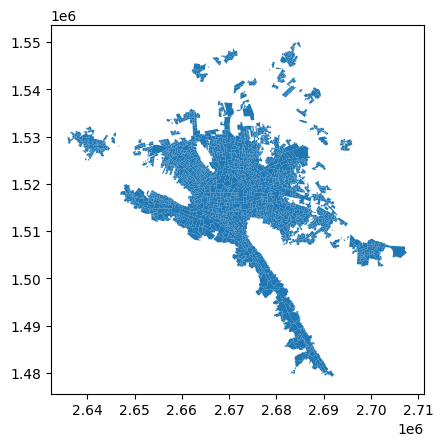

In [11]:
agebs[2020].plot()

# Add outer ring

We create an extra polygon representing the exterior to obtain additional intersections. This polygon has `cvegeo="OUT"`.

In [12]:
def add_outer_ring(agebs: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    agebs = agebs.assign(geometry=lambda df: df["geometry"].make_valid())
    outer_poly = get_outer_polygon(agebs)
    return gpd.GeoDataFrame(pd.concat([agebs, outer_poly], ignore_index=True))

In [13]:
agebs_extended = {year: add_outer_ring(agebs) for year, agebs in agebs.items()}

<Axes: >

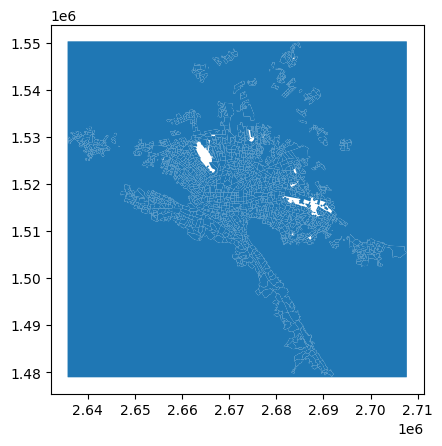

In [14]:
agebs_extended[2020].plot()

# Control points

## Initial

Control points are aligned directly to 2010 (i.e., 1990 -> 2010 and 2000 -> 2010).

- **Source:** DataFrame to align
- **Target:** DataFrame to use as reference

In [15]:
df_source = agebs_extended[1990]
df_target = agebs_extended[2010]

For both DataFrames, we calculate all intersections of three or more geometries. Afterwards, we save the IDs of each one to a list:

**Note:** Here we can add additional alignment points. For instance, AGEB centroids

In [16]:
vertices_source = get_vertices(df_source)
vertices_target = get_vertices(df_target)

list(vertices_source)[0]

frozenset({'1902600010798', '1902600011762', '1902600011777'})

This means AGEBs `1903900010495`, `1903900010616`, and `1903900010620` intersect each other.

Then, we compute the actual intersection coordinates, as a dictionary of `<set of IDS>: Point`

In [17]:
source_geoms = get_clique_geometries(df_source, vertices_source)
target_geoms = get_clique_geometries(df_target, vertices_target)

print(source_geoms[frozenset({"1903900012468", "1903900012792", "1903900012805"})])

POINT (2668595.3088999987 1509435.680300001)


Finally, we turn both dicts into Pandas Series, concat them, and drop any rows with `NaN`s. The only rows that survive are the ones that have an intersection with the same ID in both the source and target geometries:

In [18]:
pd.concat(
    [pd.Series(source_geoms, name="source"), pd.Series(target_geoms, name="target")],
    axis=1,
).dropna().head(5)

,source,target
"frozenset({1902600011762, 1902600010798, 1902600011777})",POINT (2677725.1533999965 1513220.6920000017),POINT (2677548.6906881346 1513227.2816906811)
"frozenset({1903900012862, OUT, 1903900012839})",POINT (2670212.4428000003 1507840.2010999992),POINT (2670308.793528214 1507407.5227841346)
"frozenset({1903900013818, 1903900012576, 1903900012561})",POINT (2662334.8161000013 1524421.3781999983),POINT (2662330.8548708023 1524445.8146120757)
"frozenset({1902600011283, 1902600010957, 1902600011279})",POINT (2681330.112499997 1520755.3447000012),POINT (2681297.069933813 1520776.403879147)
"frozenset({1904900010133, 1904900010114, 1904900010148})",POINT (2685475.2606000006 1487170.639800001),POINT (2685407.977641794 1487195.394088406)


These are our initial GCPs. The following function does the concatting, and a bunch of additional formatting to make it compatible with GDAL's `.points` file format:

In [19]:
df_points = merge_columns(source_geoms, target_geoms)
df_points.head(5)

,mapX,mapY,sourceX,sourceY,enable,dX,dY,residual
"frozenset({1902600011762, 1902600010798, 1902600011777})",2.677549e+06,1.513227e+06,2.677725e+06,1.513221e+06,1,0,0,0
"frozenset({1903900012862, OUT, 1903900012839})",2.670309e+06,1.507408e+06,2.670212e+06,1.507840e+06,1,0,0,0
"frozenset({1903900013818, 1903900012576, 1903900012561})",2.662331e+06,1.524446e+06,2.662335e+06,1.524421e+06,1,0,0,0
"frozenset({1902600011283, 1902600010957, 1902600011279})",2.681297e+06,1.520776e+06,2.681330e+06,1.520755e+06,1,0,0,0
"frozenset({1904900010133, 1904900010114, 1904900010148})",2.685408e+06,1.487195e+06,2.685475e+06,1.487171e+06,1,0,0,0


These GCPs will then be loaded into QGIS' georeferencer, and manually edited. The resultant files are saved into `<DATA_PATH>/intermediate/gcp`

## Additional

We load the modified GCPs and convert them to a numpy array:

In [20]:
df_gcp = pd.read_csv(
    data_path / "intermediate" / "gcp" / "1990" / f"{MET_ZONE}.points", skiprows=1
)

gcp_arr = df_gcp[["sourceX", "sourceY", "mapX", "mapY"]].to_numpy()

Then, we turn them into a GDAL command:

In [21]:
options_str = generate_options_str(gcp_arr, transform_options="-tps")
print(options_str[:100])

-tps -t_srs EPSG:6372 -gcp 2665434.1099999994 1517307.991700004 2665476.821027701 1517311.6840739334


Finally, we translate the geometries. We need to write them to disk for GDAL to work:

In [23]:
agebs_translated = {}

for year in (1990, 2000):
    with tempfile.NamedTemporaryFile(suffix=".gpkg") as temp_file:
        out_path = Path(temp_file.name)
        agebs[year].to_file(out_path, driver="GPKG")
        agebs_translated[year] = translate_geometries_single(out_path, options_str)

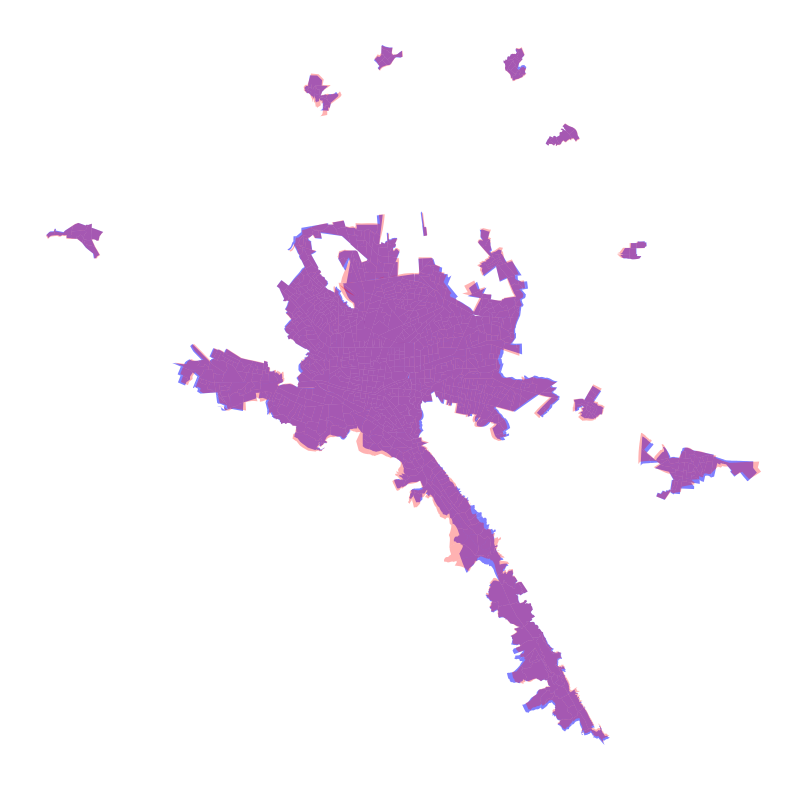

In [39]:
fig, ax = plt.subplots(figsize=(12, 8))

agebs[1990].plot(ax=ax, fc="blue", alpha=0.5)
agebs_translated[1990].plot(ax=ax, fc="r", alpha=0.3)
ax.axis("off")
fig.tight_layout()